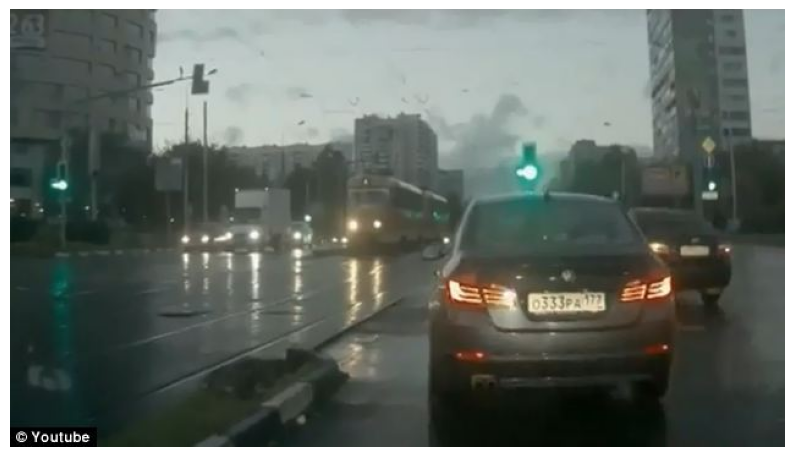

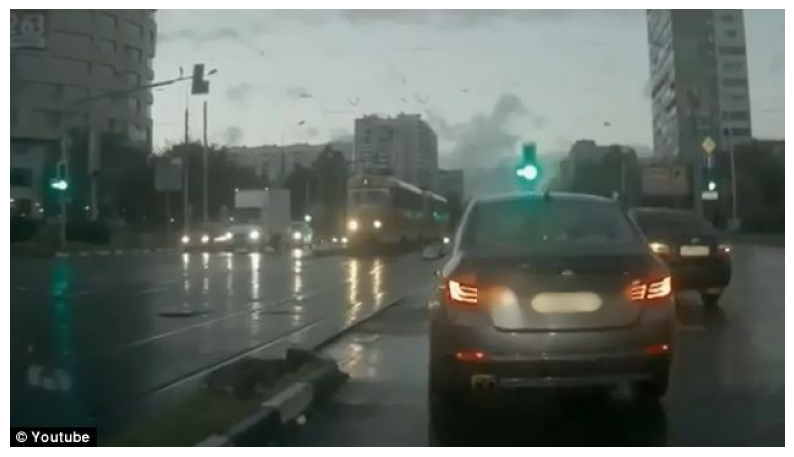

In [1]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("car_plate.jpg")
def display(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(img_rgb)
    plt.axis('off')
display(img)
import os

plate_cascade = cv2.CascadeClassifier(os.path.join(cv2.data.haarcascades, "haarcascade_russian_plate_number.xml"))
def detect_plate(img):
    img_copy = img.copy()
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

    plates = plate_cascade.detectMultiScale(gray,
                                            scaleFactor=1.1,
                                            minNeighbors=4)

    for (x, y, w, h) in plates:
        cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0,255,0), 3)

    return img_copy

result = detect_plate(img)
def detect_and_blur_plate(img):
    img_copy = img.copy()
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

    plates = plate_cascade.detectMultiScale(gray,
                                            scaleFactor=1.1,
                                            minNeighbors=4)

    for (x, y, w, h) in plates:
        roi = img_copy[y:y+h, x:x+w]     # Grab license plate
        blurred_roi = cv2.medianBlur(roi, 15) # Blur using kernel size 15
        img_copy[y:y+h, x:x+w] = blurred_roi  # Paste back

    return img_copy

result = detect_and_blur_plate(img)
display(result)